In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import kagglehub
import kagglehub
# Download latest version
path = kagglehub.dataset_download("yasserh/walmart-dataset")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/walmart-dataset


                     Store  Weekly_Sales  Holiday_Flag  Temperature  \
Store         1.000000e+00     -0.335332 -4.386841e-16    -0.022659   
Weekly_Sales -3.353320e-01      1.000000  3.689097e-02    -0.063810   
Holiday_Flag -4.386841e-16      0.036891  1.000000e+00    -0.155091   
Temperature  -2.265908e-02     -0.063810 -1.550913e-01     1.000000   
Fuel_Price    6.002295e-02      0.009464 -7.834652e-02     0.144982   
CPI          -2.094919e-01     -0.072634 -2.162091e-03     0.176888   
Unemployment  2.235313e-01     -0.106176  1.096028e-02     0.101158   
Year          3.474318e-12     -0.018378 -5.678257e-02     0.064269   
Month         2.910676e-15      0.076143  1.229958e-01     0.235862   
Week          3.106283e-15      0.074211  1.277427e-01     0.236183   

              Fuel_Price       CPI  Unemployment          Year         Month  \
Store           0.060023 -0.209492      0.223531  3.474318e-12  2.910676e-15   
Weekly_Sales    0.009464 -0.072634     -0.106176 -1.837754

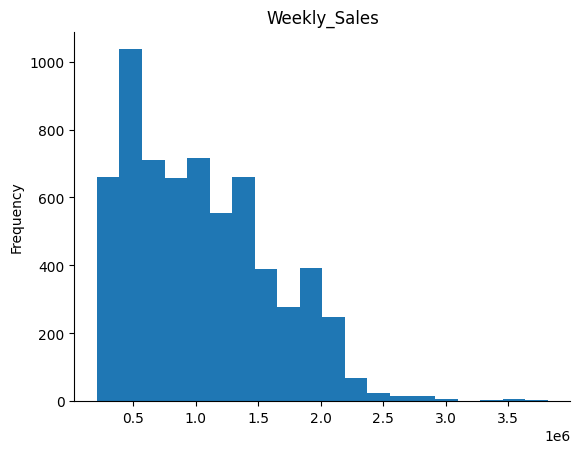

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
dataset = pd.read_csv(path+"/Walmart.csv")
df = pd.DataFrame(dataset)
df['Date'] = pd.to_datetime(df['Date'],format= "%d-%m-%Y")
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df = df.drop(columns='Date')
df.dropna()
df.head(5)
from matplotlib import pyplot as plt
df['Weekly_Sales'].plot(kind='hist', bins=20, title='Weekly_Sales')
plt.gca().spines[['top', 'right',]].set_visible(False)
correlation_matrix = df.corr()
print(correlation_matrix)

x=df.drop(columns="Weekly_Sales")
y=df["Weekly_Sales"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=1)

In [7]:
! : pip install xgboost
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
param_grid = {
'n_estimators': [500, 1000],
'learning_rate': [0.05, 0.1],
'max_depth': [3, 5],
'subsample': [0.8, 1],
'colsample_bytree': [0.8, 1]
}
xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='neg_mean_absolute_error',
cv=3,
n_jobs=-1,
verbose=1
)
grid_search.fit(x_train, y_train)
print(" Best Hyperparameters:", grid_search.best_params_)
print(" Best Negative MAE Score:", grid_search.best_score_)
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np


Fitting 3 folds for each of 32 candidates, totalling 96 fits
 Best Hyperparameters: {'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 0.8}
 Best Negative MAE Score: -54071.13880962566


In [10]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

xgb_model = XGBRegressor(
    colsample_bytree=1,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=1000,
    subsample=0.8,
    random_state=42
)
xgb_model.fit(x_train, y_train)

rfr_model = RandomForestRegressor(n_estimators=1000, random_state=1)
rfr_model.fit(x_train, y_train)


RandomForestRegressor(n_estimators=1000, random_state=1)

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Cross-validation for XGBoost model
mae_scores = cross_val_score(xgb_model, x, y, cv=5, scoring='neg_mean_absolute_error')
mae_scores = -mae_scores  # Convert to positive values

print("Cross-Validated MAE scores:", mae_scores)
print("Average MAE:", np.mean(mae_scores))


Cross-Validated MAE scores: [639954.98823621 544070.9884965  394041.7968007  647653.74343046
 388656.34355041]
Average MAE: 522875.5721028554


In [12]:
df_test = x_test.copy()
df_test["Holiday_Flag"] = x_test["Holiday_Flag"]


In [13]:
import numpy as np

# Define Weighted Mean Absolute Error
def WMAE(df, targets, predictions):
    weights = df["Holiday_Flag"].apply(lambda x: 5 if x == 1 else 1)
    return np.round(np.sum(weights * abs(targets - predictions)) / np.sum(weights), 2)

# Make predictions using the trained models
y_pred_xgb = xgb_model.predict(x_test)
y_pred_rfr = rfr_model.predict(x_test)


In [16]:
def evaluate_performance(y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    wmae = WMAE(df_test, y_test, y_pred)
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score (Accuracy): {r2:.2f}")
    print(f"Weighted Mean Absolute Error (wMAE): {wmae:.2f}")
evaluate_performance(y_pred_xgb)

Mean Absolute Error (MAE): 46823.26
Root Mean Squared Error (RMSE): 80897.01
R² Score (Accuracy): 0.98
Weighted Mean Absolute Error (wMAE): 54575.24


In [17]:
evaluate_performance(y_pred_rfr)

Mean Absolute Error (MAE): 55761.49
Root Mean Squared Error (RMSE): 99986.83
R² Score (Accuracy): 0.97
Weighted Mean Absolute Error (wMAE): 67265.29


In [18]:
import numpy as np

# Define Weighted Mean Absolute Error
def WMAE(df, targets, predictions):
    weights = df["Holiday_Flag"].apply(lambda x: 5 if x == 1 else 1)
    return np.round(np.sum(weights * abs(targets - predictions)) / np.sum(weights), 2)

# Make predictions using the trained models
y_pred_xgb = xgb_model.predict(x_test)
y_pred_rfr = rfr_model.predict(x_test)


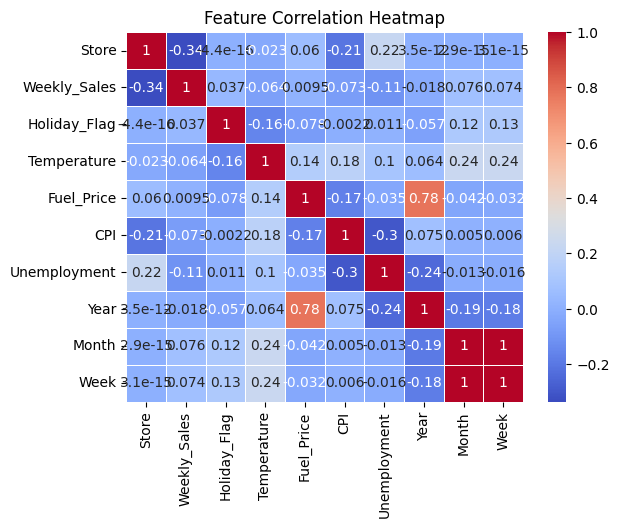

In [19]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

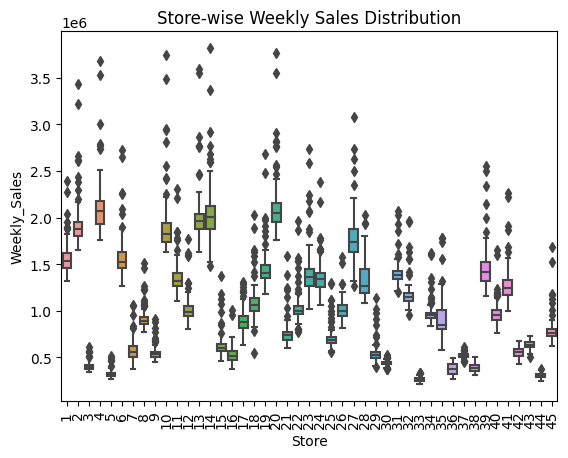

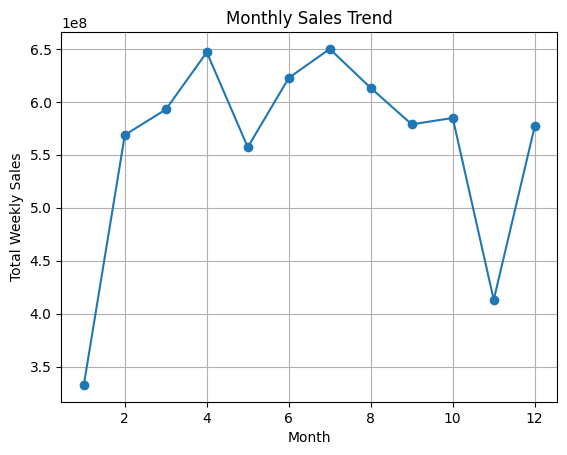

In [21]:
sns.boxplot(x="Store", y="Weekly_Sales", data=df)
plt.title("Store-wise Weekly Sales Distribution")
plt.xticks(rotation=90)
plt.show()
import matplotlib.pyplot as plt
df.groupby('Month')['Weekly_Sales'].sum().plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Weekly Sales")
plt.grid(True)
plt.show()

In [24]:
expected_columns = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
'CPI', 'Unemployment', 'Year', 'Month', 'Week']
test_input = pd.DataFrame([{
'Store': 1,
'Holiday_Flag': 0,
'Temperature': 60.5,
'Fuel_Price': 3.25,
'CPI': 220.5,
'Unemployment': 7.5,
'Year': 2012,
'Month': 11,
'Week': 46
}], columns=expected_columns)
# Predict weekly sales for the test input using XGBoost model
prediction = xgb_model.predict(test_input)

# Print the predicted sales value
print(f"🛍️ Predicted Weekly Sales: ${prediction[0]:,.2f}")


🛍️ Predicted Weekly Sales: $1,614,781.00
